# Shared four-source latent rollout: no history versus three-frame history

One shared autoencoder is trained across Reid, low-temperature de Pablo,
mixed-temperature de Pablo, and noisy LJ. The frozen latent representation is
then used by two propagators: a frame-0 delta-z model and a three-observed-frame
history model. Model selection uses validation rollout p-ratio only; p-ratio is
never included in either training loss.


In [1]:
%matplotlib inline
import hashlib, json, os, sys
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lss.latent.experiment import run_latent_experiment, seed_everything
from lss.latent.simulation import pearson_r, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, style_axes
from lss.utils import resolve_device
apply_editorial_style()
DEVICE = resolve_device('auto')
print(f'Device: {DEVICE}')


Device: cuda


/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
SEED = 20260806
FORCE_TRAIN_AE = False
FORCE_TRAIN_PROPAGATORS = False
LATENT_DIM = 2
VAL_PER_SOURCE = 5
ROLLOUT_STEPS = [25, 50, 75, 100, 125, 150, 175, 199]

# No source identity, temperature, box variable, or p-ratio is supplied to the models.
DATASETS = {
    'reid': {
        'label': 'Reid', 'train_count': 20,
        'path': PROJECT_ROOT/'data'/'reid_200_frames.pt',
    },
    'depablo_low_temp': {
        'label': 'de Pablo low-T', 'train_count': 5,
        'path': PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt',
    },
    'depablo_mixed_temp': {
        'label': 'de Pablo mixed-T', 'train_count': 5,
        'path': PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt',
    },
    'lj_noisy': {
        'label': 'noisy LJ', 'train_count': 50, 'edge_vector_dim': 8,
        'path': PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_500sims_200frames.pt',
    },
}
for spec in DATASETS.values():
    assert spec['path'].exists(), spec['path']

AE_CONFIG = {
    'latent_dim': LATENT_DIM, 'latent_tokens': 32, 'hidden_size': 96,
    'autoencoder_model': 'attention', 'batch_graphs': 64,
    'ae_max_train_frames_per_sim': 150,
    'ae_val_frame_skip': 4, 'ae_max_val_frames_per_sim': 150,
    'ae_max_epochs': 60, 'ae_patience': 8,
    'ae_lr': 2e-4, 'ae_weight_decay': 1e-5,
}
PROPAGATOR_CONFIG = {
    'dyn_max_train_transitions_per_sim': 150,
    'dyn_max_epochs': 80, 'dyn_patience': 12,
    'dyn_lr': 2e-4, 'dyn_weight_decay': 1e-5,
    'propagator_hidden_size': 128,
    'graph_context_dim': 16,
    'rollout_eval_sims_per_source': 10,
}

OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'06c_shared_multiphysics_history_rollout'
OUTPUT.mkdir(parents=True, exist_ok=True)
cache_identity = {
    'seed': SEED,
    'datasets': {key: {'path': str(value['path']), 'train': value['train_count']} for key,value in DATASETS.items()},
    'val': VAL_PER_SOURCE, 'ae': AE_CONFIG,
}
cache_tag = hashlib.sha1(json.dumps(cache_identity, sort_keys=True).encode()).hexdigest()[:12]
AE_CACHE = OUTPUT/f'shared_four_source_ae_cv{LATENT_DIM}_{cache_tag}.pt'
print({
    'training_networks': sum(spec['train_count'] for spec in DATASETS.values()),
    'validation_networks': VAL_PER_SOURCE*len(DATASETS),
    'latent_dim': LATENT_DIM,
    'AE_cache': str(AE_CACHE),
})


{'training_networks': 80, 'validation_networks': 20, 'latent_dim': 2, 'AE_cache': '/home/alexz/Documents/course_project/notebooks/results/06c_shared_multiphysics_history_rollout/shared_four_source_ae_cv2_afb1c7ca95e6.pt'}


## Train the shared autoencoder once

In [3]:
mixture = [
    {
        'name': key, 'label': spec['label'], 'path': str(spec['path']),
        'train_count': spec['train_count'], 'val_count': VAL_PER_SOURCE,
        'edge_vector_dim': spec.get('edge_vector_dim', 2),
    }
    for key,spec in DATASETS.items()
]

def base_config():
    return {
        'dataset_name': 'mixed_four_sources_shared',
        'split_seed': SEED, 'split_stratify_temperature': False,
        'min_train_p_ratio': None, 'device': str(DEVICE), 'pos_dim': 2,
        'batch_graphs': AE_CONFIG['batch_graphs'], 'frame_skip': 1,
        'train_frame_start_order': 0,
        'latent_dim': AE_CONFIG['latent_dim'], 'latent_tokens': AE_CONFIG['latent_tokens'],
        'hidden_size': AE_CONFIG['hidden_size'],
        'autoencoder_model': AE_CONFIG['autoencoder_model'], 'edge_feature_dim': 12,
        'ae_target_mode': 'normalized_delta', 'node_feature_mode': 'normalized_delta',
        'ae_max_train_frames_per_sim': AE_CONFIG['ae_max_train_frames_per_sim'],
        'ae_val_frame_skip': AE_CONFIG['ae_val_frame_skip'],
        'ae_max_val_frames_per_sim': AE_CONFIG['ae_max_val_frames_per_sim'],
        'ae_max_epochs': AE_CONFIG['ae_max_epochs'], 'ae_patience': AE_CONFIG['ae_patience'],
        'ae_lr': AE_CONFIG['ae_lr'], 'ae_weight_decay': AE_CONFIG['ae_weight_decay'],
        'temperature_pratio_window': 'full',
        'rollout_steps_grid': ROLLOUT_STEPS,
        'early_stop_min_delta': 1e-5,
        'model_seed': SEED, 'repeat_idx': 1,
    }

def source_spec(label):
    cfg = base_config()
    return {
        'dataset_name': cfg['dataset_name'], 'source_name': 'four-source mixture',
        'label': label, 'path': str(DATASETS['reid']['path']),
        'dataset_mixture': mixture,
        'target_mode': cfg['ae_target_mode'],
        'ae_target_mode': cfg['ae_target_mode'],
        'node_feature_mode': cfg['node_feature_mode'],
        **{key: cfg[key] for key in [
            'latent_dim','latent_tokens','hidden_size','autoencoder_model','edge_feature_dim',
            'ae_max_train_frames_per_sim','ae_max_epochs','ae_patience','ae_lr','ae_weight_decay',
            'model_seed','repeat_idx',
        ]},
    }

ae_cfg = base_config()
ae_cfg.update({
    'should_rollout': False, 'should_train_propagator': False,
    'force_train': FORCE_TRAIN_AE, 'cache_path': str(AE_CACHE),
})
print('Loading four datasets and training/loading the shared AE ...', flush=True)
seed_everything(SEED)
ae_result = run_latent_experiment(source_spec('shared four-source AE'), ae_cfg, device=DEVICE)
display(ae_result['split_info'])
display(ae_result['ae_history'].tail())


Loading four datasets and training/loading the shared AE ...



=== shared four-source AE ===
            source                                                                                                 path  total  train  reserved_train_pool  val  test
              reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     20                   20    5    77
  depablo_low_temp                                  /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200      5                    5    5   190
depablo_mixed_temp                                    /home/alexz/Documents/course_project/data/depablo-10k-mix-temp.pt    300      5                    5    5   290
          lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_500sims_200frames.pt    500     50                   50    5   445
autoencoder
ae 0001 train=0.639166 val=0.979252 stale=0
ae 0002 train=0.425851 val=0.802895 stale=0
ae 0003 train=0.360597 val=0.485862 sta

,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,20,20,5,77
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,5,5,5,190
2,depablo_mixed_temp,/home/alexz/Documents/course_project/data/depa...,300,5,5,5,290
3,lj_noisy,/home/alexz/Documents/course_project/data/lj-n...,500,50,50,5,445


,epoch,train_objective,val_objective,train_mse_norm,val_mse_norm,dataset,latent_dim,target_mode,hidden_size
12,13,0.318680,0.467697,0.318680,0.467697,shared four-source AE,2,normalized_delta,96
13,14,0.317714,0.472837,0.317714,0.472837,shared four-source AE,2,normalized_delta,96
14,15,0.316948,0.481766,0.316948,0.481766,shared four-source AE,2,normalized_delta,96
15,16,0.316669,0.468584,0.316669,0.468584,shared four-source AE,2,normalized_delta,96
16,17,0.315516,0.465251,0.315516,0.465251,shared four-source AE,2,normalized_delta,96


## Train the two propagators on the frozen latent space

In [ ]:
PROPAGATOR_MODES = {
    'no_history': {
        'label': 'no history',
        'propagator_objective': 'one_step',
        'propagator_model': 'delta_mlp',
        'rollout_history_frames': 1,
    },
    'history_3': {
        'label': '3 observed frames',
        'propagator_objective': 'history_one_step',
        'propagator_model': 'history_mlp',
        'rollout_history_frames': 3,
        'initial_velocity': 'three_frames',
    },
}

results = {}
for mode_key, mode in PROPAGATOR_MODES.items():
    cfg = base_config()
    prop_cache = OUTPUT/f'{mode_key}_cv{LATENT_DIM}_{cache_tag}.pt'
    cfg.update({
        'pretrained_ae_cache_path': str(AE_CACHE),
        'pretrained_ae_require_matching_normalizers': True,
        'dyn_max_train_transitions_per_sim': PROPAGATOR_CONFIG['dyn_max_train_transitions_per_sim'],
        'dyn_max_epochs': PROPAGATOR_CONFIG['dyn_max_epochs'],
        'dyn_patience': PROPAGATOR_CONFIG['dyn_patience'],
        'dyn_lr': PROPAGATOR_CONFIG['dyn_lr'],
        'dyn_weight_decay': PROPAGATOR_CONFIG['dyn_weight_decay'],
        'propagator_hidden_size': PROPAGATOR_CONFIG['propagator_hidden_size'],
        'propagator_objective': mode['propagator_objective'],
        'propagator_model': mode['propagator_model'],
        'propagator_loss': 'delta', 'propagator_step_stride': 1,
        'propagator_use_static_context': True,
        'graph_context_dim': PROPAGATOR_CONFIG['graph_context_dim'],
        'propagator_context_include_temperature': False,
        'propagator_context_pool': 'mean',
        'rollout_history_frames': mode['rollout_history_frames'],
        'propagator_rollout_eval_every_epoch': True,
        'propagator_rollout_eval_horizons': [100],
        'propagator_rollout_eval_sims_per_source': PROPAGATOR_CONFIG['rollout_eval_sims_per_source'],
        'propagator_checkpoint_metric': 'val_rollout_min_source_p_ratio_r2',
        'propagator_checkpoint_mode': 'max',
        'rollout_eval_max_sims_per_split': None,
        'should_rollout': True, 'should_train_propagator': True,
        'force_train': FORCE_TRAIN_PROPAGATORS,
        'cache_path': str(prop_cache),
    })
    if 'initial_velocity' in mode:
        cfg['initial_velocity'] = mode['initial_velocity']
    spec = source_spec(f"shared four-source {mode['label']} rollout")
    spec.update({
        'pretrained_ae_cache_path': str(AE_CACHE),
        'pretrained_ae_require_matching_normalizers': True,
        'dyn_max_train_transitions_per_sim': cfg['dyn_max_train_transitions_per_sim'],
        'dyn_max_epochs': cfg['dyn_max_epochs'], 'dyn_patience': cfg['dyn_patience'],
        'dyn_lr': cfg['dyn_lr'], 'dyn_weight_decay': cfg['dyn_weight_decay'],
    })
    print(f"Training/loading propagator: {mode['label']} ...", flush=True)
    seed_everything(SEED)
    results[mode_key] = run_latent_experiment(spec, cfg, device=DEVICE)
    history = results[mode_key]['dyn_history'].copy()
    display(history.tail())


Training/loading propagator: no history ...


## Held-out rollout p-ratio

Test p-ratio R² versus rollout horizon. Negative R² is displayed at zero.


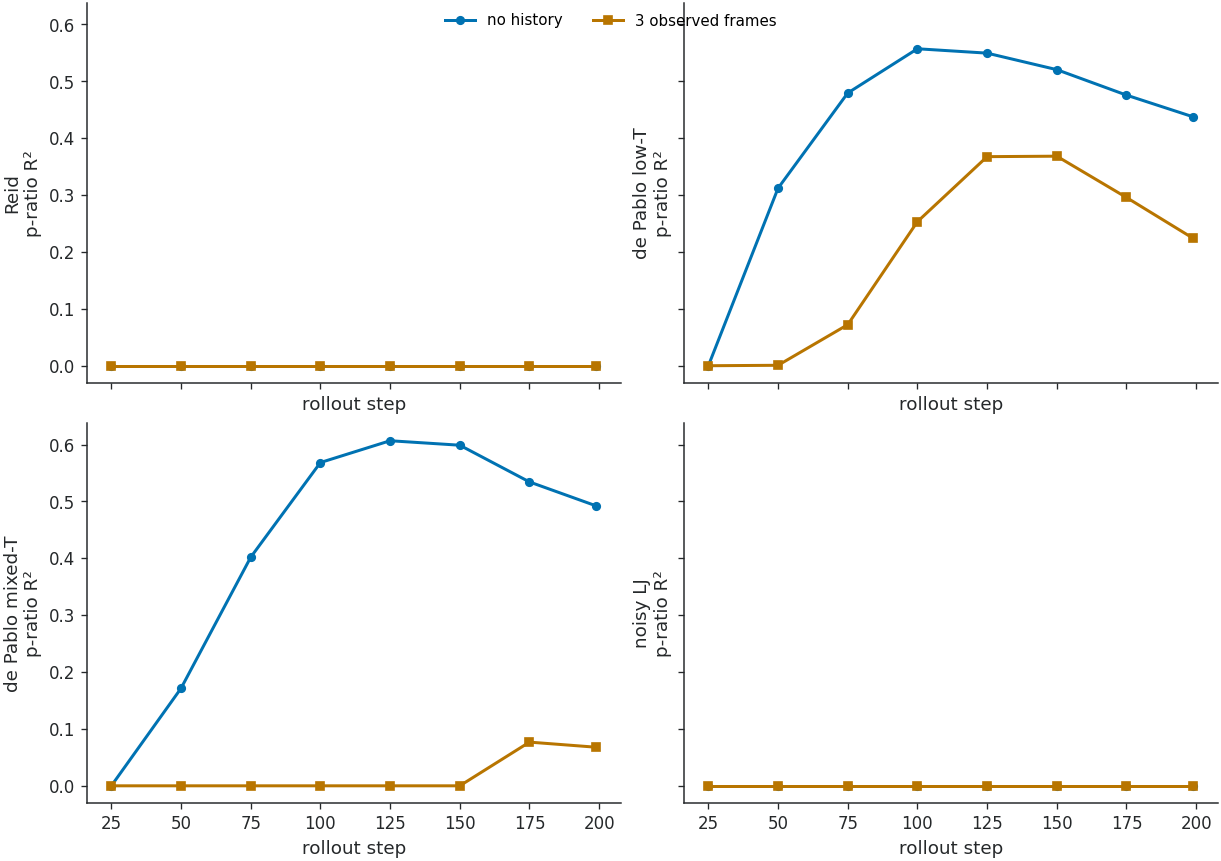

n_networks            p_ratio_r2             \
mode                            history_3 no_history  history_3 no_history   
source_family    rollout_steps                                               
Reid             100                 77.0       77.0     -2.590     -1.032   
                 150                 77.0       77.0     -4.167     -0.900   
                 199                 77.0       77.0     -6.732     -0.340   
de Pablo low-T   100                175.0      175.0      0.253      0.557   
                 150                175.0      175.0      0.368      0.521   
                 199                175.0      175.0      0.224      0.437   
de Pablo mixed-T 100                272.0      275.0     -0.222      0.568   
                 150                274.0      275.0     -0.053      0.599   
                 199                275.0      275.0      0.068      0.492   
noisy LJ         100                470.0      470.0     -2.116     -1.156   
                 150                470.0      470.0     -2.237     -1.305   
                 199                470.0      470.0     -2.441     -1.930   

                               pearson_r             
mode                           history_3 no_history  
source_family    rollout_steps                       
Reid             100              -0.215      0.275  
                 150              -0.057      0.362  
                 199               0.168      0.431  
de Pablo low-T   100               0.877      0.927  
                 150               0.880      0.936  
                 199               0.845      0.935  
de Pablo mixed-T 100               0.740      0.937  
                 150               0.770      0.950  
                 199               0.777      0.942  
noisy LJ         100               0.010     -0.001  
                 150              -0.007     -0.021  
                 199              -0.017     -0.022

In [ ]:
SOURCE_LABELS = {key: spec['label'] for key,spec in DATASETS.items()}
MODE_COLORS = {
    'no_history': PAPER_COLORS['blue'],
    'history_3': PAPER_COLORS['orange'],
}
MODE_MARKERS = {'no_history': 'o', 'history_3': 's'}

rollout_parts = []
for mode_key, result in results.items():
    source_lookup = {
        index: SOURCE_LABELS.get(
            str(getattr(sim[0], 'source_name', '')),
            str(getattr(sim[0], 'source_name', 'unknown')),
        )
        for index,sim in enumerate(result['test_data'])
    }
    rows = result['rollout_rows'].query("split == 'test'").copy()
    rows['source_family'] = rows.sim_idx.map(source_lookup)
    rows['mode'] = mode_key
    rollout_parts.append(rows)
rollout_rows = pd.concat(rollout_parts, ignore_index=True)
rollout_rows.to_csv(OUTPUT/'heldout_rollout_rows.csv', index=False)

summary_rows = []
for (mode, source_family, step), group in rollout_rows.groupby(['mode','source_family','rollout_steps']):
    valid = group[['true_p_ratio','pred_p_ratio']].replace([np.inf,-np.inf],np.nan).dropna()
    summary_rows.append({
        'mode': mode, 'source_family': source_family,
        'rollout_steps': int(step),
        'p_ratio_r2': r2_score(valid.true_p_ratio, valid.pred_p_ratio) if len(valid) >= 2 else np.nan,
        'pearson_r': pearson_r(valid.true_p_ratio, valid.pred_p_ratio) if len(valid) >= 2 else np.nan,
        'n_networks': len(valid),
    })
rollout_summary = pd.DataFrame(summary_rows)
rollout_summary.to_csv(OUTPUT/'heldout_pratio_rollout_summary.csv', index=False)

print('Test p-ratio R² versus rollout horizon. Negative R² is displayed at zero.')
fig, axes = plt.subplots(2, 2, figsize=(10.2, 7.2), sharex=True, sharey=True, constrained_layout=True)
for ax, source_family in zip(axes.flat, SOURCE_LABELS.values()):
    for mode_key, mode in PROPAGATOR_MODES.items():
        group = rollout_summary[
            rollout_summary.source_family.eq(source_family)
            & rollout_summary['mode'].eq(mode_key)
        ].sort_values('rollout_steps')
        ax.plot(
            group.rollout_steps, np.maximum(group.p_ratio_r2, 0),
            color=MODE_COLORS[mode_key], marker=MODE_MARKERS[mode_key],
            lw=1.8, ms=4.5, label=mode['label'],
        )
    style_axes(ax, xlabel='rollout step', ylabel=f'{source_family}\np-ratio R²', legend=False)
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
fig.savefig(OUTPUT/'history_vs_no_history_pratio_r2.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT/'history_vs_no_history_pratio_r2.pdf', bbox_inches='tight')
plt.show()

selected = rollout_summary[rollout_summary.rollout_steps.isin([100,150,199])]
display(selected.pivot_table(
    index=['source_family','rollout_steps'], columns='mode', values=['p_ratio_r2','pearson_r','n_networks']
).round(3))


## Frame-100 rollout scatter

Held-out p-ratio at frame 100: no history.


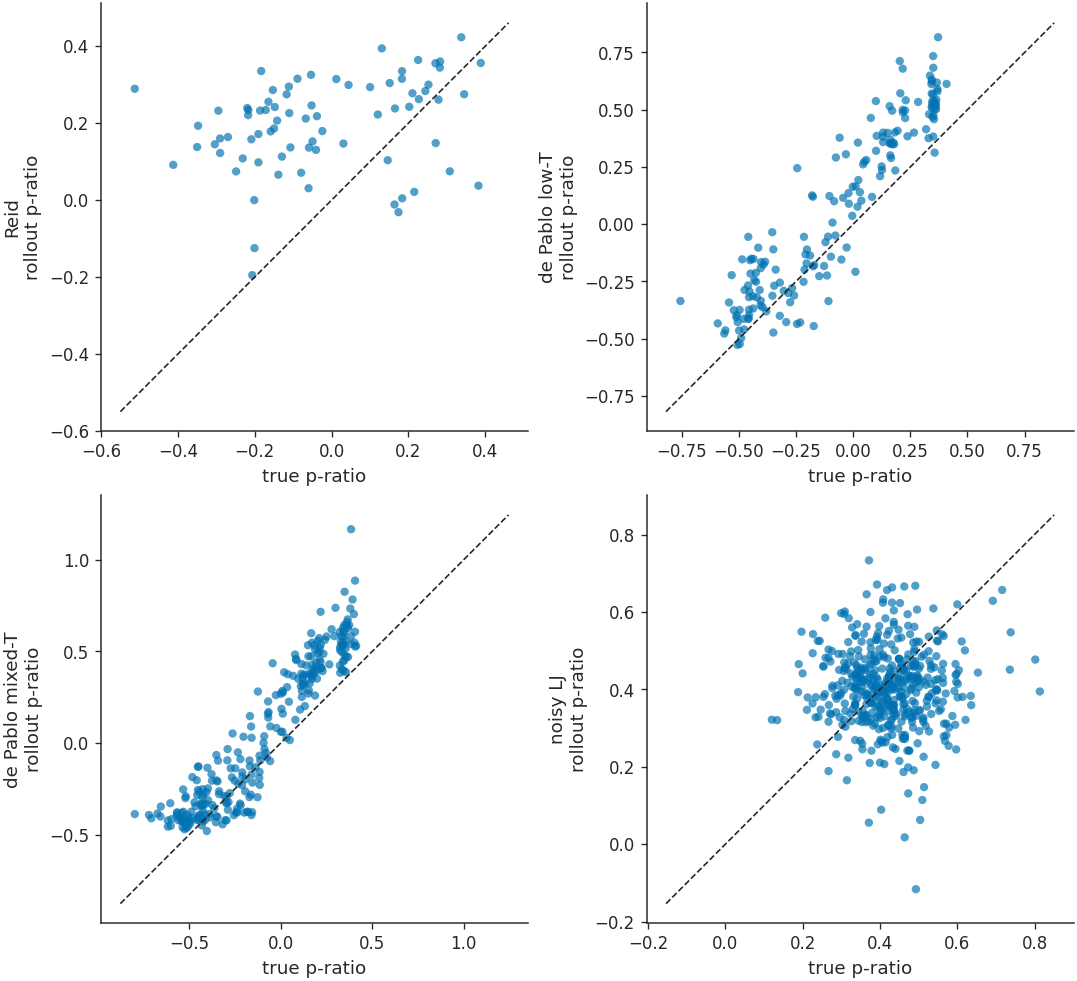

Held-out p-ratio at frame 100: 3 observed frames.


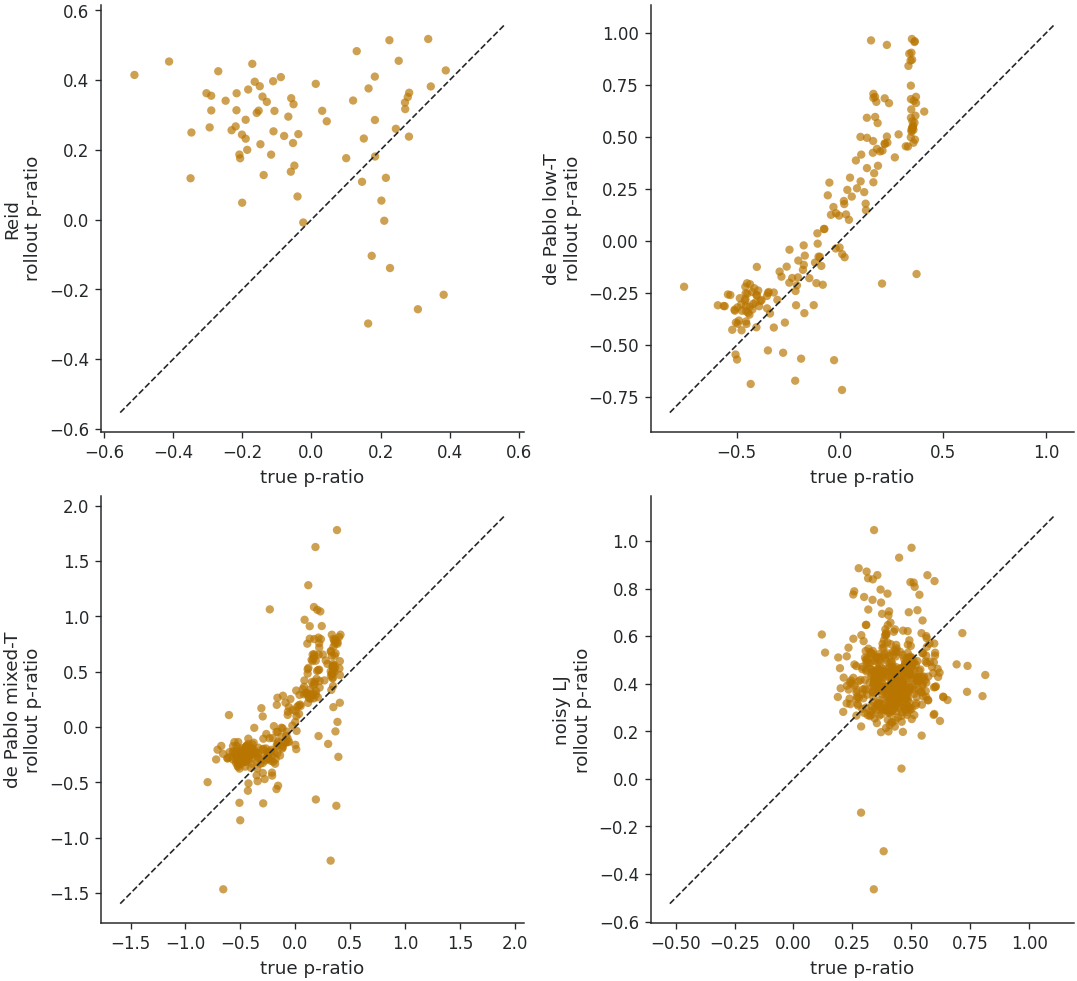

In [ ]:
for mode_key, mode in PROPAGATOR_MODES.items():
    print(f"Held-out p-ratio at frame 100: {mode['label']}.")
    selected = rollout_rows[
        rollout_rows['mode'].eq(mode_key) & rollout_rows.rollout_steps.eq(100)
    ].replace([np.inf,-np.inf],np.nan).dropna(subset=['true_p_ratio','pred_p_ratio'])
    fig, axes = plt.subplots(2, 2, figsize=(9.0,8.2), constrained_layout=True)
    for ax, source_family in zip(axes.flat, SOURCE_LABELS.values()):
        group = selected[selected.source_family.eq(source_family)]
        if len(group):
            ax.scatter(
                group.true_p_ratio, group.pred_p_ratio,
                s=25, alpha=.68, color=MODE_COLORS[mode_key], edgecolor='none',
            )
            limits = np.r_[group.true_p_ratio,group.pred_p_ratio]
            lo,hi = np.nanmin(limits),np.nanmax(limits)
            pad = .04*max(hi-lo,1e-6)
            ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad],'--',color=PAPER_COLORS['ink'],lw=1)
        style_axes(ax, xlabel='true p-ratio', ylabel=f'{source_family}\nrollout p-ratio', legend=False)
    fig.savefig(OUTPUT/f'{mode_key}_frame100_scatter.png',dpi=300,bbox_inches='tight')
    fig.savefig(OUTPUT/f'{mode_key}_frame100_scatter.pdf',bbox_inches='tight')
    plt.show()
